# IMPORTS

In [29]:
%pip install neurogym

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
%pip install torch

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import neurogym as ngym
env = ngym.make('DelayMatchSampleDistractor1D-v0')
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn



In [32]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tasks.poisson_dms import generate_trials as _generate_trials

In [33]:
%pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 34.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 38.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# DATA

In [23]:
def generate_trials(num_trials=1000, lam=0.0, seed=42):
    """
    Makes trials with our Poisson distractor match-to-sample task function (see poisson_dms.py)
    """
    return _generate_trials(num_trials=num_trials, lam=lam, seed=seed)


class TrialDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# MODEL

In [12]:
# one forward pass through the RNN performs one working memory matching task
class VanillaRNN(nn.Module):
    """
    Continuous-time RNN inspired by Yang et al. (2019): h_new = (1 - alpha) * h + alpha * tanh(W_rec @ h + W_in @ x + b)

    alpha = dt/tau = leak rate. This formulation gives the network a time constant that helps maintain information across delay periods
    (keep because it improves performance a ton! ^^)

    The recurrent weight matrix W_rec directly represents neuron-to-neuron connection strengths, making it easy to analyze 
    like a biological wiring diagram and can then be helpful later when we do PCA (or some other method)
    """

    def __init__(self, input_size=33, hidden_size=128, output_size=3,
                 dt=20, tau=500, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.alpha = dt / tau # leak rate: smaller = more memory retention

        # Weight matrices!
        self.W_in = nn.Linear(input_size, hidden_size)
        self.W_rec = nn.Linear(hidden_size, hidden_size, bias=False)
        self.readout = nn.Linear(hidden_size, output_size)

        # Orthogonal init for recurrent weights (standard for comp neuro RNNs according to Yang et al. 2019 & internet)
        nn.init.orthogonal_(self.W_rec.weight, gain=1.0)
        nn.init.xavier_uniform_(self.W_in.weight)
        nn.init.xavier_uniform_(self.readout.weight)

    def forward(self, x, h0=None):
        batch_size, seq_len, _ = x.shape
        if h0 is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        else:
            h = h0.squeeze(0)

        hidden_states = []
        for t in range(seq_len):
            # Continuous-time RNN update: leaky integration ( Yang et al. 2019)
            h = (1 - self.alpha) * h + self.alpha * torch.tanh(
                self.W_in(x[:, t]) + self.W_rec(h)
            )
            hidden_states.append(h)

        hidden_states = torch.stack(hidden_states, dim=1) #(batch, time, hidden)
        predictions = self.readout(hidden_states)
        return predictions, hidden_states




# TRAINING

In [24]:
def train_model(
    model, train_loader, val_loader=None, num_epochs=50, learning_rate=1e-3, checkpoint_dir='checkpoints', 
    checkpoint_every=10, device='cpu', #likely cant get gpu :(
    class_weights=None, 
):
    os.makedirs(checkpoint_dir, exist_ok=True) #checkpoints
    model = model.to(device)

    # Cross-entropy loss with class weighting -- important so network can't cheat by always predicting "do nothing" (90% of timesteps)
    loss_function = nn.CrossEntropyLoss(
        weight=class_weights.to(device) if class_weights is not None else None
    )

    # we use default Adam optimizer for now
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'train_acc': [], 'train_dec_acc': [],
        'val_loss': [], 'val_acc': [], 'val_dec_acc': [],
    }

    for epoch in range(1, num_epochs + 1):

        # batch train
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        dec_correct = 0
        dec_total = 0

        for inputs_batch, labels_batch in train_loader:
            inputs_batch = inputs_batch.to(device)
            labels_batch = labels_batch.to(device)

            #forward========
            predictions, _ = model(inputs_batch)

            loss = loss_function(
                predictions.reshape(-1, predictions.size(-1)),
                labels_batch.reshape(-1),
            )

            #backward=========
            optimizer.zero_grad()
            loss.backward()

            # clip gradients to prevent exploding gradients (common in vanilla RNNs)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            # metrics
            running_loss += loss.item() * inputs_batch.size(0)
            predicted_classes = predictions.argmax(dim=-1)
            correct += (predicted_classes == labels_batch).sum().item()
            total += labels_batch.numel()

            # Decision accuracy = match/non-match during test periods
            is_decision = (labels_batch >= 1) # labels 1 (=match) or 2 (=non-match)
            if is_decision.any():
                dec_correct += (predicted_classes[is_decision] == labels_batch[is_decision]).sum().item()
                dec_total += is_decision.sum().item()

        # Record epochwide metrics
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        train_dec_acc = dec_correct / dec_total if dec_total > 0 else 0.0

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_dec_acc'].append(train_dec_acc)

        # Validation
        val_loss, val_acc, val_dec_acc = None, None, None
        if val_loader is not None:
            val_loss, val_acc, val_dec_acc = evaluate(
                model, val_loader, loss_function, device
            )
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['val_dec_acc'].append(val_dec_acc)

        msg = f"Epoch {epoch:3d}/{num_epochs} | "
        msg += f"Loss: {train_loss:.4f}  DecAcc: {train_dec_acc:.4f}"
        if val_loss is not None:
            msg += f" | ValLoss: {val_loss:.4f}  ValDecAcc: {val_dec_acc:.4f}"
        print(msg)

        # Save checkpoint with recurrent weight matrix 
        if epoch % checkpoint_every == 0 or epoch == num_epochs:
            checkpoint = {
                
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'train_acc': train_acc,
                'val_loss': val_loss,
                'val_acc': val_acc,
                'W_hh': model.W_rec.weight.detach().cpu().numpy(),
                'W_ih': model.W_in.weight.detach().cpu().numpy(),
            }
            path = os.path.join(checkpoint_dir, f'epoch_{epoch:03d}.pt')
            torch.save(checkpoint, path)
            print(f"  -> Checkpoint saved: {path}")

    return history


def evaluate(model, loader, loss_function, device='cpu'):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    dec_correct = 0
    dec_count = 0

    with torch.no_grad():
        for inputs_batch, labels_batch in loader:
            inputs_batch = inputs_batch.to(device)
            labels_batch = labels_batch.to(device)

            predictions, _ = model(inputs_batch)
            loss = loss_function(
                predictions.reshape(-1, predictions.size(-1)),
                labels_batch.reshape(-1),
            )

            total_loss += loss.item() * inputs_batch.size(0)
            predicted_classes = predictions.argmax(dim=-1)
            total_correct += (predicted_classes == labels_batch).sum().item()
            total_count += labels_batch.numel()

            is_decision = (labels_batch >= 1)  # labels 1 (match) or 2 (non-match)
            if is_decision.any():
                dec_correct += (predicted_classes[is_decision] == labels_batch[is_decision]).sum().item()
                dec_count += is_decision.sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / total_count
    dec_accuracy = dec_correct / dec_count if dec_count > 0 else 0.0
    return avg_loss, accuracy, dec_accuracy

In [25]:
# hyperparameters
NUM_TRAIN_TRIALS = 5000
NUM_VAL_TRIALS = 500
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
HIDDEN_SIZE = 128
CHECKPOINT_EVERY = 10
LAM = 1.0  # lambda for Poisson distractor rate (0 = no distractors/default)


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(f"Using device: {DEVICE}")
# print(f"Distractor rate (lambda): {LAM}")
print("generating training/val trials")
X_train, Y_train, infos_train = generate_trials(
    num_trials=NUM_TRAIN_TRIALS, lam=LAM, seed=42
)
print(f"input shape {X_train.shape}")
print(f"labels shape {Y_train.shape}")
print(f"unique labels {np.unique(Y_train)}")
# print("val trials generating")
X_val, Y_val, infos_val = generate_trials(
    num_trials=NUM_VAL_TRIALS, lam=LAM, seed=99,
)


# Compute class weights to handle imbalance
# (most timesteps are "do nothing", only ~10% are actual decisions)
num_classes = len(np.unique(Y_train))
class_counts = np.bincount(Y_train.flatten(), minlength=num_classes)
total_samples = class_counts.sum()
class_weights = torch.tensor(
    total_samples / (num_classes * class_counts),
    dtype=torch.float32,
)
print(f"  Class counts: {dict(enumerate(class_counts))}")
print(f"  Class weights: {class_weights.tolist()}")


train_loader = DataLoader(
    TrialDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TrialDataset(X_val, Y_val), batch_size=BATCH_SIZE, shuffle=False
)

model = VanillaRNN(
    input_size=33,
    hidden_size=HIDDEN_SIZE,
    output_size=num_classes,
)
print(f"\nModel architecture:\n{model}")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

checkpoint_dir = os.path.join('checkpoints', f'poisson_lam{LAM}')
history = train_model(
    model, train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    checkpoint_dir=checkpoint_dir, checkpoint_every=CHECKPOINT_EVERY,
    device=DEVICE, class_weights=class_weights,
)


np.savez(
    os.path.join(checkpoint_dir, 'training_history.npz'),
    train_loss=history['train_loss'], train_acc=history['train_acc'],
    train_dec_acc=history['train_dec_acc'], val_loss=history['val_loss'],
    val_acc=history['val_acc'], val_dec_acc=history['val_dec_acc'],
)
print("Done! Training history saved too.")

Using device: cpu
Distractor rate (lambda): 1.0
Generating training trials...
Input shape:  (5000, 215, 33)
Labels shape: (5000, 215)
Unique labels: [0 1 2]
Generating validation trials...
  Class counts: {0: np.int64(950000), 1: np.int64(61750), 2: np.int64(63250)}
  Class weights: [0.37719297409057617, 5.802968978881836, 5.665349006652832]

Model architecture:
VanillaRNN(
  (W_in): Linear(in_features=33, out_features=128, bias=True)
  (W_rec): Linear(in_features=128, out_features=128, bias=False)
  (readout): Linear(in_features=128, out_features=3, bias=True)
)
Total trainable parameters: 21,123
Epoch   1/100 | Loss: 0.6369  DecAcc: 0.4900 | ValLoss: 0.5240  ValDecAcc: 0.5461
Epoch   2/100 | Loss: 0.5259  DecAcc: 0.5021 | ValLoss: 0.5066  ValDecAcc: 0.5355
Epoch   3/100 | Loss: 0.5107  DecAcc: 0.5193 | ValLoss: 0.5129  ValDecAcc: 0.5338
Epoch   4/100 | Loss: 0.5054  DecAcc: 0.5040 | ValLoss: 0.4946  ValDecAcc: 0.5410
Epoch   5/100 | Loss: 0.4979  DecAcc: 0.5153 | ValLoss: 0.4906  Val

# ANALYSIS

## Distraction Fidelity

In [ ]:
# Hidden state extraction
def extract_hidden_states(model, X, device='cpu'):#no gpu
    """
    Run the trained model & record all 64 neurons' activity over time.
    """
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        _, hidden_states = model(X_tensor)
    return hidden_states.cpu().numpy()

# Extract hidden states for later analysis (PCA, stability, etc.)
print("extracting hidden states from trained model")
hidden_states = extract_hidden_states(model, X_val[:50], device=DEVICE)
print(f"hidden states shape: {hidden_states.shape}")
np.save(os.path.join(checkpoint_dir, 'hidden_states_val.npy'), hidden_states)
print(f"Saved to {checkpoint_dir}/hidden_states_val.npy")



Extracting hidden states from trained model...
Hidden states shape: (50, 215, 128)
Saved to checkpoints/poisson_lam1.0/hidden_states_val.npy


In [ ]:
H = extract_hidden_states(model, X_val, device=DEVICE)
target_angles = np.array([info['target_angle'] for info in infos_val])
boundaries = infos_val[0]['boundaries'] 

In [ ]:
from sklearn.linear_model import Ridge

def fit_angle_decoder(model, lam0_X, lam0_infos, boundaries, device='cpu', alpha=1.0):
    """
    Fit a ridge decoder from sample-period hidden states to [sin(angle), cos(angle)]. Note, we need to use sin/cos because
    otherwise angles close to 0 and alngles close to 2pi may be considered quite different
    
    Use clean (lam=0) trials to train the decoder (so it's a fixed readout) which is based on Hallenbeck et al.'s use of an 
    independent IEM training dataset.
    """
    H = extract_hidden_states(model, lam0_X, device=device) 
    target_angles = np.array([info['target_angle'] for info in lam0_infos])
    s, e = boundaries['sample']
    H_sample = H[:, s:e, :] # (N, sample_steps, hidden) 
    N, S, D = H_sample.shape
    X_dec = H_sample.reshape(N * S, D) #(N*S, hidden)
    
    # "Tiling" needed in this situation
    angles_tiled = np.repeat(target_angles, S)  # (N*S,)
    Y_dec = np.column_stack([np.sin(angles_tiled), np.cos(angles_tiled)])  # (N*S, 2)
    
    decoder = Ridge(alpha=alpha) #Ridge performs best
    decoder.fit(X_dec, Y_dec)
    return decoder

def decode_angles(decoder, hidden_states):
    """
    Given the fitted decoder apply it to hidden states at every timestep. return decoded_angles: (N, T) — angles in radians
    """
    N, T, D = hidden_states.shape
    H_flat = hidden_states.reshape(N * T, D)
    sin_cos = decoder.predict(H_flat) # (N*T, 2) ->
    angles = np.arctan2(sin_cos[:, 0], sin_cos[:, 1]) # (N*T,)
    return angles.reshape(N, T)

def compute_fidelity(decoded_angles, true_angles):
    """
    Hallenbeck paper's definition of fidelity: projection of decoded representation onto true direction.
    Fidelity (T,) = mean cos(decoded - true) across trials at each timestep
    """
    diff = decoded_angles - true_angles[:, np.newaxis]
    return np.cos(diff).mean(axis=0) # (T,)

Sample-period mean fidelity (clean): 0.998


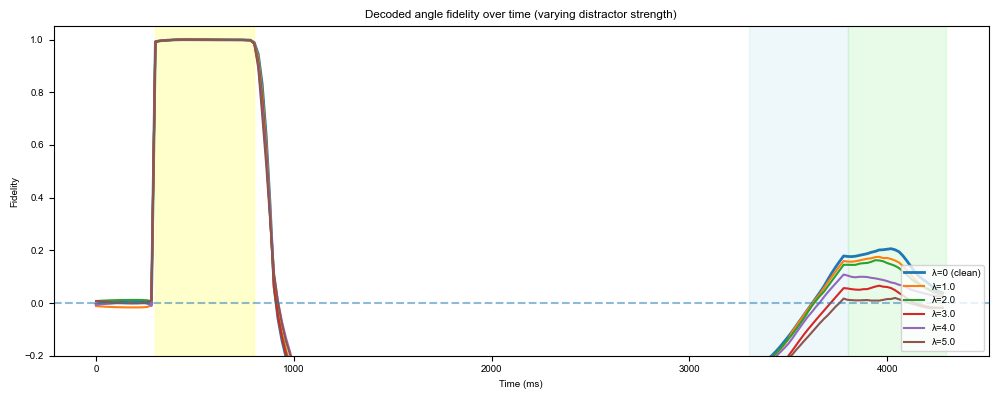

In [39]:
dt = 20
# fidelity should be near 1.0 throughout the delay for clean trials
# clean trials for decoder fitting (always lam=0)
X_clean, _, infos_clean = generate_trials(num_trials=1000, lam=0.0, seed=999)
boundaries = infos_clean[0]['boundaries']

decoder = fit_angle_decoder(model, X_clean, infos_clean, boundaries, device=DEVICE)


H_clean = extract_hidden_states(model, X_clean, device=DEVICE)
target_clean = np.array([info['target_angle'] for info in infos_clean])
decoded_clean = decode_angles(decoder, H_clean)
fid_clean = compute_fidelity(decoded_clean, target_clean)

# should be > 0.9ish (after all, when presented with the angle without distractors or delay, the fidelity should be high)
print(f"Sample-period mean fidelity (clean): {fid_clean[boundaries['sample'][0]:boundaries['sample'][1]].mean():.3f}")


lambdas = [1.0, 2.0, 3.0, 4.0, 5.0]   # add as many as you want
fid_dict = {}

for lam in lambdas:
    X_dist, _, infos_dist = generate_trials(num_trials=1000, lam=lam, seed=1234)
    H_dist = extract_hidden_states(model, X_dist, device=DEVICE)
    target_dist = np.array([info['target_angle'] for info in infos_dist])
    decoded_dist = decode_angles(decoder, H_dist)
    fid_dist = compute_fidelity(decoded_dist, target_dist)
    
    fid_dict[lam] = fid_dist

# plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))

time_ms = np.arange(len(fid_clean)) * dt

# baseline
ax.plot(time_ms, fid_clean, label='λ=0 (clean)', linewidth=2)

# distractor curves
for lam, fid in fid_dict.items():
    ax.plot(time_ms, fid, label=f'λ={lam}')

# period shading
period_colors = {'sample': 'yellow', 'test': 'lightblue', 'decision': 'lightgreen'}
for p, color in period_colors.items():
    s, e = boundaries[p]
    ax.axvspan(s * dt, e * dt, alpha=0.2, color=color)

ax.axhline(0, linestyle='--', alpha=0.5)

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Fidelity')
ax.set_title('Decoded angle fidelity over time (varying distractor strength)')
ax.legend(loc='lower right')
ax.set_ylim(-0.2, 1.05)

plt.tight_layout()
plt.show()

## Inspection

In [15]:

def inspect_trial(trial_idx=0, data_path='trial_data_seed123.npz',
                  checkpoint_dir='checkpoints/poisson_lam0.0', hidden_size=128):
    """
    Visualize a single trial: input heatmap, P(match)/P(non-match), predicted vs true class, and correctness.
    """
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Requires presaved data from generate_trials with seed=123
    data = np.load(data_path, allow_pickle=True)
    X = data['X']
    Y = data['Y']
    output_size = int(np.max(Y)) + 1

    names = list(data['boundary_names'])
    starts = data['boundary_starts']
    ends = data['boundary_ends']
    boundaries = {n: (int(s), int(e)) for n, s, e in zip(names, starts, ends)}

    # Trial metadata
    gt_label = int(data['ground_truths'][trial_idx])
    sample_angle = float(data['sample_thetas'][trial_idx])
    test_angle = float(data['test_thetas'][trial_idx])
    match_str = 'MATCH' if gt_label == 1 else 'NON-MATCH'

    # Model
    ckpts = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith('.pt')])
    latest = os.path.join(checkpoint_dir, ckpts[-1])
    print(f'Loading: {latest}')
    model = VanillaRNN(input_size=33, hidden_size=hidden_size, output_size=output_size)
    state = torch.load(latest, map_location=device, weights_only=False)
    model.load_state_dict(state['model_state_dict'])
    model.to(device).eval()

    # Forward 
    with torch.no_grad():
        x = torch.tensor(X[trial_idx:trial_idx+1], dtype=torch.float32).to(device)
        logits, hidden = model(x)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        preds = logits.argmax(dim=-1).cpu().numpy()[0]

    y_true = Y[trial_idx]

# ===========
    print(f'Trial {trial_idx} | sample={sample_angle:.2f} rad | '
          f'test={test_angle:.2f} rad | {match_str}')
    for p in ['test', 'decision']:
        s, e = boundaries[p]
        counts = np.bincount(preds[s:e], minlength=output_size)
        print(f'  {p}: preds={counts.tolist()}, '
              f'P(match)={probs[s:e, 1].mean():.3f}, '
              f'P(non-match)={probs[s:e, 2].mean():.3f}')

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

    axes[0].imshow(X[trial_idx].T, aspect='auto', cmap='viridis')
    axes[0].set_ylabel('Input channel')
    axes[0].set_title(f'Trial {trial_idx} | {match_str} | '
                      f'sample={sample_angle:.2f} test_angle={test_angle:.2f}')

    axes[1].plot(probs[:, 1], color='C1', label='P(match)')
    axes[1].plot(probs[:, 2], color='C3', label='P(non-match)')
    axes[1].set_ylabel('Probability')
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[1].legend(loc='upper left', fontsize=8)

    axes[2].plot(y_true, color='black', linewidth=2,
                 label='Y (true)', drawstyle='steps-post')
    axes[2].plot(preds, color='C2', linewidth=1.5, alpha=0.8,
                 label='pred', drawstyle='steps-post')
    axes[2].set_ylabel('Class')
    axes[2].set_yticks(range(output_size))
    axes[2].legend(loc='upper left', fontsize=8)
    axes[2].set_ylim(-0.3, output_size - 0.7)

    correct = (preds == y_true).astype(int)
    axes[3].fill_between(range(len(correct)), 0, correct,
                         color='green', alpha=0.4, step='post')
    axes[3].fill_between(range(len(correct)), 0, 1 - correct,
                         color='red', alpha=0.4, step='post')
    axes[3].set_ylabel('Correct')
    axes[3].set_ylim(-0.05, 1.05)
    axes[3].set_xlabel('Timestep')

    shade = {'sample': ('yellow', 0.25), 'test': ('lightblue', 0.25),
             'decision': ('lightyellow', 0.15)}
    for p, (s, e) in boundaries.items():
        if p in shade:
            color, alpha = shade[p]
            for ax in axes:
                ax.axvspan(s, e, alpha=alpha, color=color)
        mid = (s + e) / 2
        axes[0].text(mid, -0.5, p, ha='center', va='top', fontsize=7,
                     color='gray', transform=axes[0].get_xaxis_transform())

    plt.tight_layout()
    plt.show()

    return {'probs': probs, 'preds': preds, 'y_true': y_true,
            'boundaries': boundaries, 'hidden': hidden.cpu().numpy()[0]}


In [59]:
from tasks.poisson_dms import generate_trials
import numpy as np

def generate_data_for_save(data_lam):
    X, Y, infos = generate_trials(num_trials=100, lam=data_lam, seed=123)

    ground_truths = np.array([1 if i['is_match'] else 2 for i in infos])
    sample_thetas = np.array([i['target_angle'] for i in infos])
    test_thetas = np.array([i['test_angle'] for i in infos])

    b = infos[0]['boundaries']
    names = ['fixation', 'sample', 'delay', 'test', 'decision']
    starts = np.array([b[n][0] for n in names])
    ends = np.array([b[n][1] for n in names])

    np.savez(f'trial_data_seed123_lam{data_lam}.npz',
        X=X, Y=Y,
        ground_truths=ground_truths,
        sample_thetas=sample_thetas,
        test_thetas=test_thetas,
        boundary_names=names,
        boundary_starts=starts,
        boundary_ends=ends)


generate_data_for_save(data_lam=0)

Loading: checkpoints/poisson_lam0.0/epoch_100.pt
Trial 78 | sample=1.63 rad | test=1.92 rad | NON-MATCH
  test: preds=[24, 0, 1], P(match)=0.000, P(non-match)=0.038
  decision: preds=[0, 0, 25], P(match)=0.000, P(non-match)=0.999


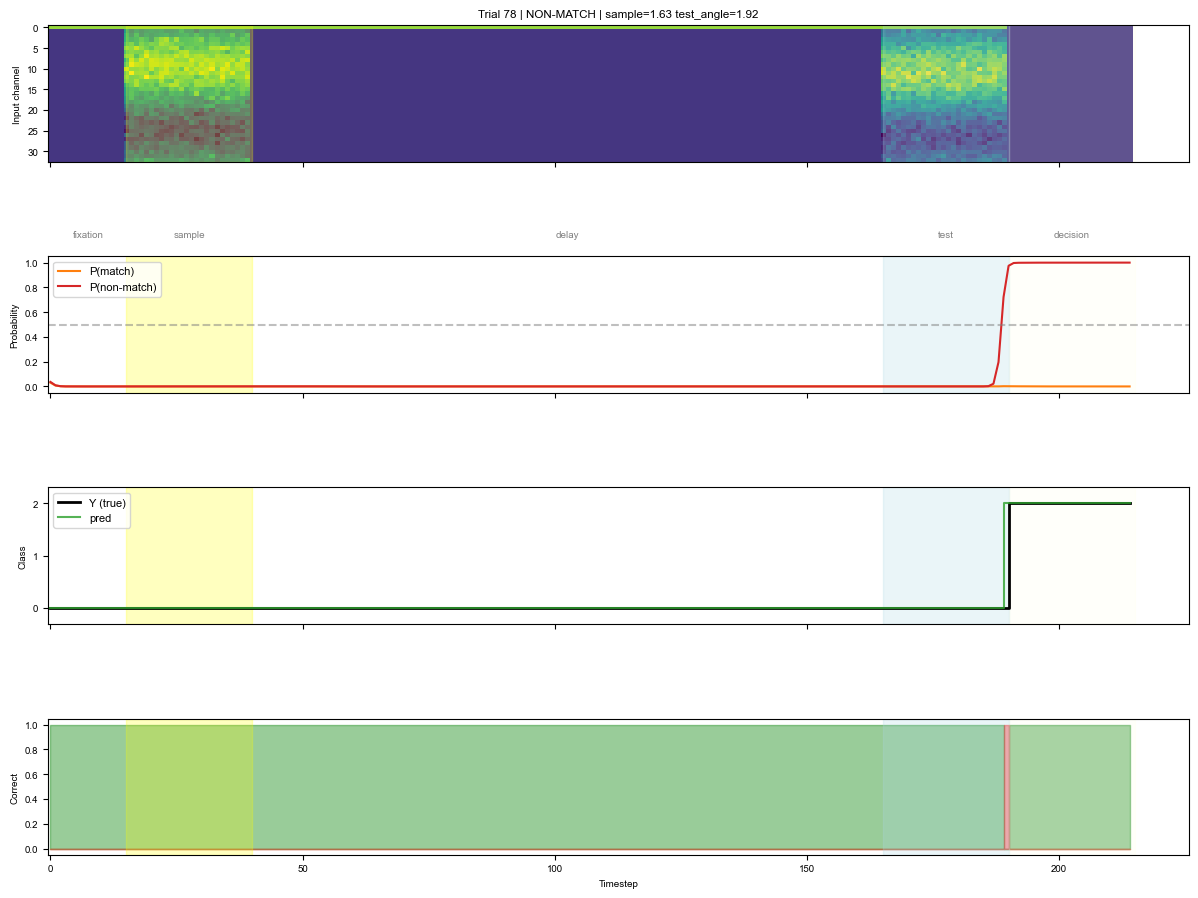

In [60]:
# trial_idx can go from 0-99
result = inspect_trial(trial_idx=78, data_path='trial_data_seed123_lam0.npz')